In [1]:
from neuron import h
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
import numpy as np
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots
from synapse_basket import SynapseBasket
import matplotlib.pyplot as plt
from copy import deepcopy

# TI influence on subthreshold synaptic plasticity

Soma is inhibited by inhibitory basket cell:

- soma / proximal apical dendrites
- GABAergic (GABA A - fast inhibition)
- activated a few ms after CA3 inputs

After, model CA3 synapses at the strength that results in LTP. EPSPs in the dendritic tree should be relatively large.

In [2]:
def generate_poisson(
        frequency = 5,
        burst_duration = 50,
        duration = 1000,
        rate_in_burst = 100,
        rate_outside_burst = 1
):
    burst_times = np.arange(0, duration, 1000 / frequency)
    spike_times = []

    for t_burst in burst_times:
        # Generate Poisson spikes inside the burst window
        n_spikes = np.random.poisson(rate_in_burst * (burst_duration / 1000))
        spikes = t_burst + np.random.uniform(0, burst_duration, size = n_spikes)
        spike_times.extend(spikes)

        # Generate sparse spikes outside bursts
        outside_duration = (1000 / frequency) - burst_duration
        if outside_duration > 0:
            n_out = np.random.poisson(rate_outside_burst * (outside_duration / 1000))
            spikes_out = t_burst + burst_duration + np.random.uniform(0, outside_duration, size = n_out)
            spike_times.extend(spikes_out)

    spike_times = np.sort(np.array(spike_times))
    return spike_times

In [3]:
rate = 5
duration = 1 * 1000 # ms

In [4]:
# Generate a list of random seeds to use when generating stimuli
np.random.seed(132)
seeds = np.random.choice(range(10000), 20, replace = False)

seed_counter = -1


# Define the stimulus
def poisson_theta():
    global seed_counter
    seed_counter += 1

    np.random.seed(seeds[seed_counter])

    # Generate spike times
    spike_times = generate_poisson(frequency = rate, duration = duration)
    spike_vec = h.Vector(spike_times)

    stimulus = h.VecStim()
    stimulus.play(spike_vec)

    return stimulus

In [5]:
neuron = PlasticNeuron(
    n_synapses = 1,
    initial_weight = 0.2,
    initial_conductance = 0.0001,
    generate_stimulus = poisson_theta,
    # Define parameters of the basket cells
    basket_n_synapses = 1,
    basket_generate_delay = lambda: 5,
    basket_generate_stimulus = poisson_theta,
    basket_conductance = 0.005,
    basket_max_distance = 75,
    basket_fraction = dict({
        "Soma": 1,
        "Basal": 0,
        "Apical": 0
    })
)

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Generating synapse information
Inserting 1 synapses
Inserting 1 inhibitory basket synapses
Inserting basket cell in compartment: Soma


In [6]:
neuron.basket_synapse_info

,Compartment,CompartmentID,Location,Distance,Delay,Conductance
0,Soma,0,0.74155,7.851,5,0.005


## Simulation without TI

In [7]:
NeuronUtils.set_stimulus(duration = 0)
neuron.run(duration = duration)

Neuron initialized
Elapsed time: 23.12 seconds


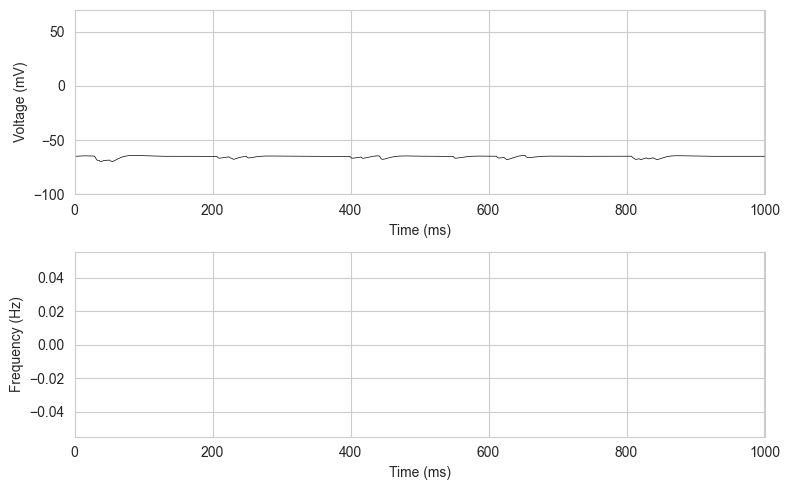

In [8]:
NeuronPlots.plot_spike_frequency(neuron)

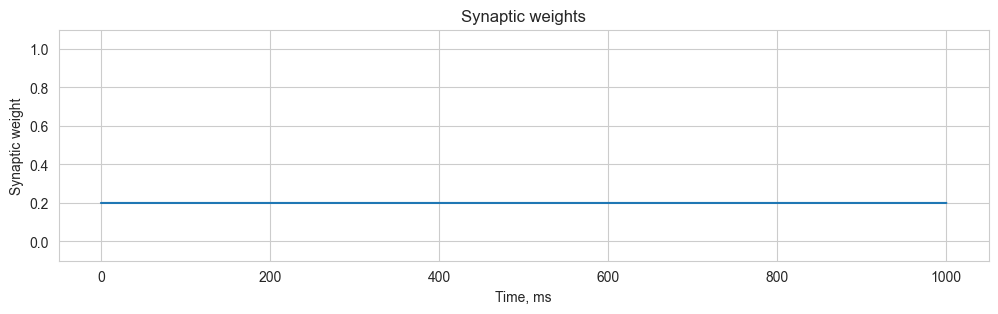

In [9]:
plt.figure(figsize = (12, 3))
NeuronPlots.plot_synaptic_weights(neuron)

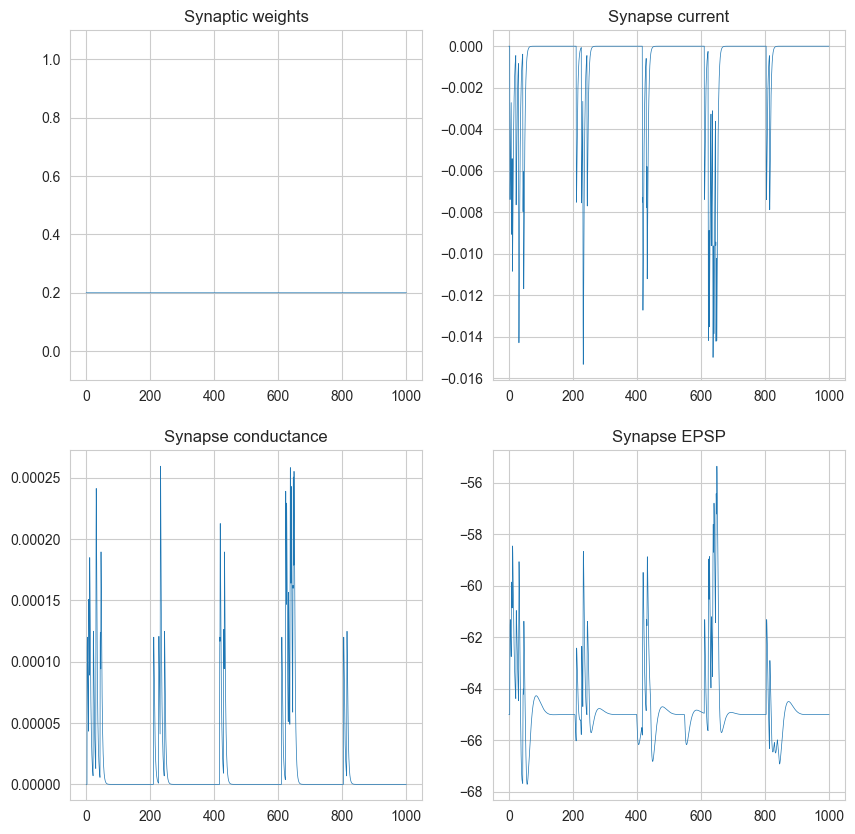

In [10]:
NeuronPlots.plot_all_synapses(neuron)

### Synapse EPSP

In [11]:
synapse = neuron.synapses[0]

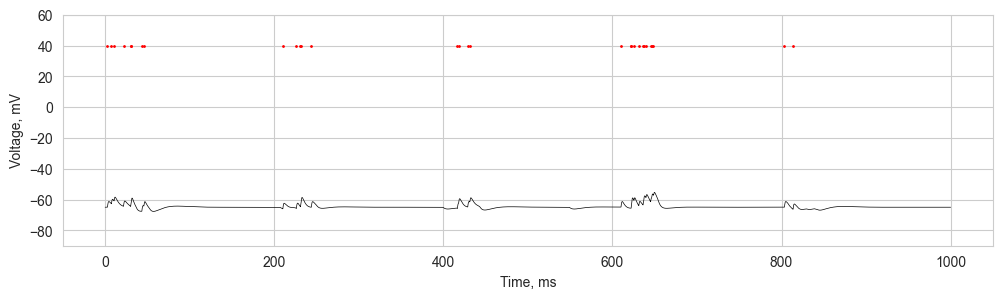

In [12]:
plt.figure(figsize = (12, 3))

plt.plot(
    neuron.time,
    synapse.voltage,
    linewidth = 0.5,
    color = "black"
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")
plt.ylim(-90, 60)

plt.scatter(
    synapse.stimuli,
    np.repeat(40, len(synapse.stimuli)),
    c = "red",
    s = 1
)

plt.show()

In [13]:
ms_before = 5
ms_after = 20

epsps = []

for stimulus in synapse.stimuli:
    start = stimulus - ms_before
    end = stimulus + ms_after
    
    if start < 0 or end > np.max(neuron.time):
        continue
    
    time_idx = np.where(np.logical_and(neuron.time >= start, neuron.time <= end))[0]
    epsps.append(synapse.voltage[ time_idx ])

epsps = np.array(epsps)
time = neuron.time[ np.where(np.logical_and(neuron.time >= 0, neuron.time < ms_before + ms_after))[0] ]

if epsps.shape[1] != time.shape[0]:
    time = time[:-1]

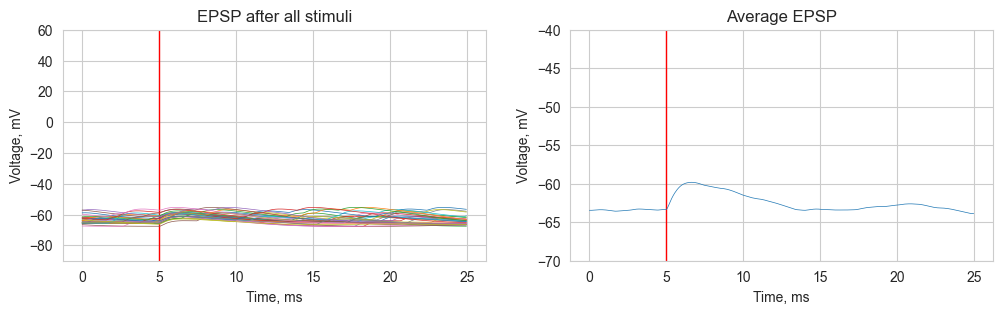

In [14]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

axs[0].vlines(ms_before, ymin = -100, ymax = 100, linewidth = 1, color = "red")

for epsp in epsps:
    axs[0].plot(
        time,
        epsp,
        linewidth = 0.5
    )

axs[0].set_xlabel("Time, ms")
axs[0].set_ylabel("Voltage, mV")
axs[0].set_ylim(-90, 60)
axs[0].set_title("EPSP after all stimuli")

axs[1].vlines(ms_before, ymin = -100, ymax = 100, linewidth = 1, color = "red")

axs[1].plot(
    time,
    np.mean(epsps, axis = 0),
    linewidth = 0.5
)

axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Voltage, mV")
axs[1].set_ylim(-70, -40)
axs[1].set_title("Average EPSP")

plt.show()

## Simulation with TI (5 Hz)

In [30]:
NeuronUtils.set_stimulus(
    duration = duration,
    frequency1 = 1000,
    frequency2 = 1005,
    amplitude = 120,
    delay = 0,
    phase = 10
)

neuron.run(duration = duration)

Neuron initialized
Elapsed time: 22.93 seconds


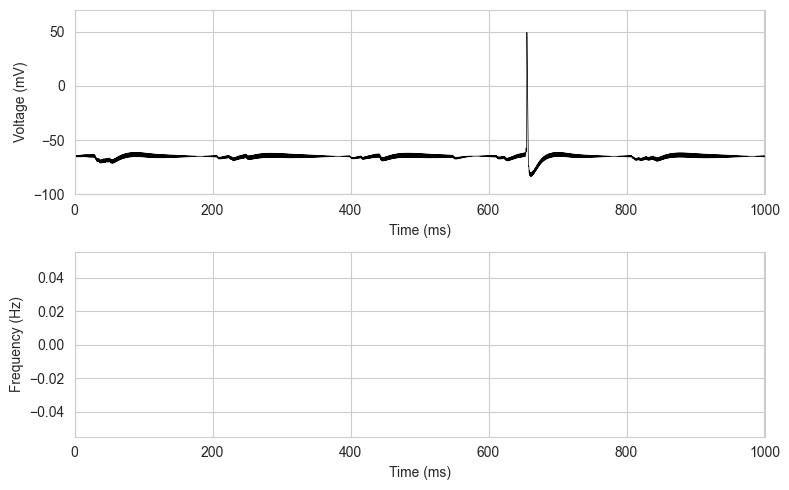

In [31]:
NeuronPlots.plot_spike_frequency(neuron)

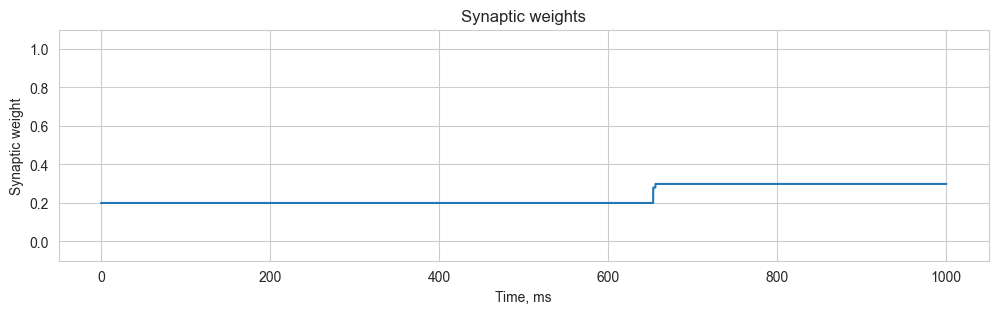

In [32]:
plt.figure(figsize = (12, 3))
NeuronPlots.plot_synaptic_weights(neuron)

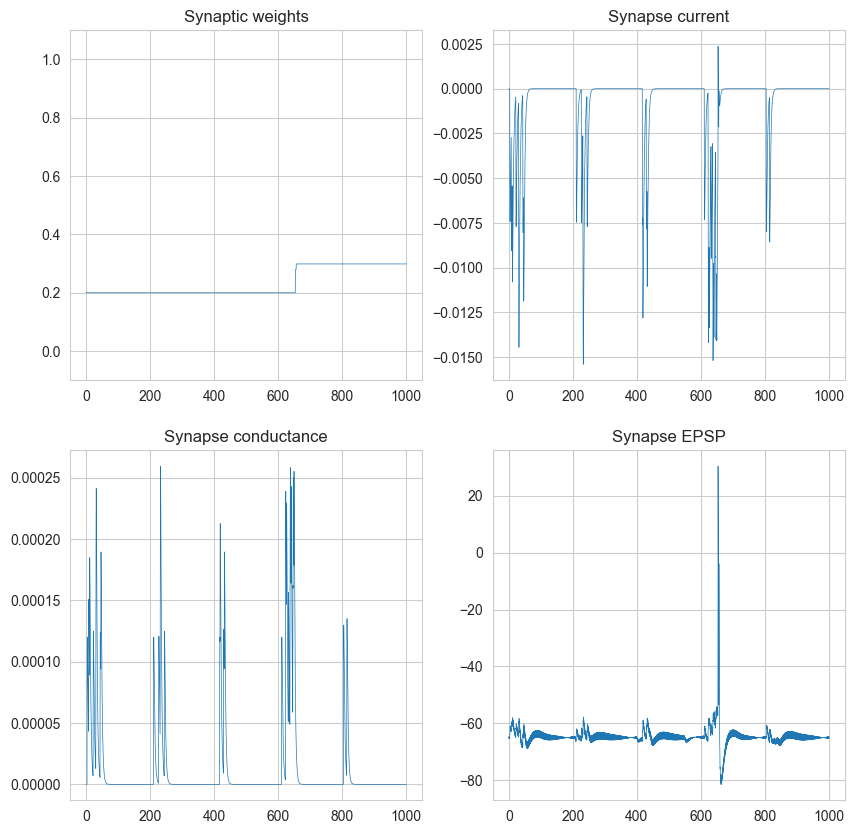

In [33]:
NeuronPlots.plot_all_synapses(neuron)

### Synapse EPSP

In [34]:
synapse = neuron.synapses[0]

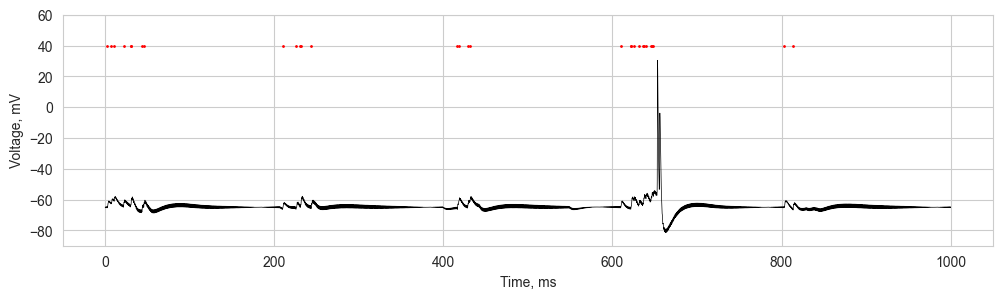

In [35]:
plt.figure(figsize = (12, 3))

plt.plot(
    neuron.time,
    synapse.voltage,
    linewidth = 0.5,
    color = "black"
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")
plt.ylim(-90, 60)

plt.scatter(
    synapse.stimuli,
    np.repeat(40, len(synapse.stimuli)),
    c = "red",
    s = 1
)

plt.show()

In [36]:
ms_before = 5
ms_after = 20

epsps_ti = []

for stimulus in synapse.stimuli:
    start = stimulus - ms_before
    end = stimulus + ms_after

    if start < 0 or end > np.max(neuron.time):
        continue

    time_idx = np.where(np.logical_and(neuron.time >= start, neuron.time <= end))[0]
    epsps_ti.append(synapse.voltage[ time_idx ])

epsps_ti = np.array(epsps_ti)
time = neuron.time[ np.where(np.logical_and(neuron.time >= 0, neuron.time < ms_before + ms_after))[0] ]

if epsps_ti.shape[1] != time.shape[0]:
    time = time[:-1]

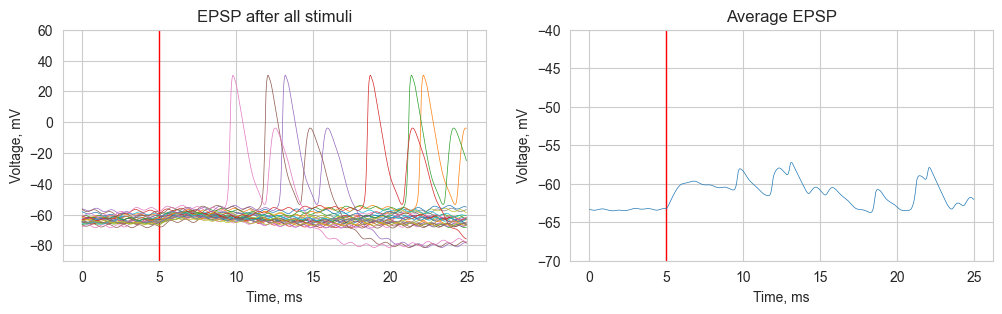

In [37]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

axs[0].vlines(ms_before, ymin = -100, ymax = 100, linewidth = 1, color = "red")

for epsp in epsps_ti:
    axs[0].plot(
        time,
        epsp,
        linewidth = 0.5
    )

axs[0].set_xlabel("Time, ms")
axs[0].set_ylabel("Voltage, mV")
axs[0].set_ylim(-90, 60)
axs[0].set_title("EPSP after all stimuli")

axs[1].vlines(ms_before, ymin = -100, ymax = 100, linewidth = 1, color = "red")

axs[1].plot(
    time,
    np.mean(epsps_ti, axis = 0),
    linewidth = 0.5
)

axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Voltage, mV")
axs[1].set_ylim(-70, -40)
axs[1].set_title("Average EPSP")

plt.show()

## Quick comparison of EPSPs

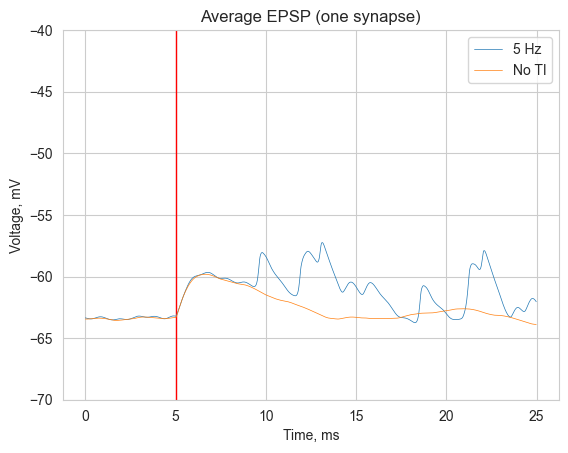

In [38]:
plt.vlines(ms_before, ymin = -100, ymax = 100, linewidth = 1, color = "red")

plt.plot(
    time,
    np.mean(epsps_ti, axis = 0),
    linewidth = 0.5,
    label = "5 Hz"
)

plt.plot(
    time,
    np.mean(epsps, axis = 0),
    linewidth = 0.5,
    label = "No TI"
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")
plt.ylim(-70, -40)
plt.title("Average EPSP (one synapse)")
plt.legend()

plt.show()